# Questao 5

Analise e filtragem do audio `handel.wav` contaminado por uma senoide de 100 Hz, uma senoide de 2000 Hz e ruido branco com variancia `sigma^2 in {10^-2, 10^-1, 1}`.

A lista pede filtros notch para tons isolados, mas esta resolucao usa apenas passa-altas e passa-baixas. Assim, o sistema escolhido e uma cascata com passa-altas em 180 Hz e passa-baixas em 1800 Hz. Essa escolha atenua a interferencia de 100 Hz e a de 2000 Hz, mas tambem remove parte do conteudo original proximo dessas faixas.

In [1]:

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()


def find_repo_root(start_path):
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'data').exists() and (candidate / 'pratica_6').exists():
            return candidate
    raise FileNotFoundError('Repositorio nao encontrado. Execute o notebook dentro da pasta do projeto.')


REPO_ROOT = find_repo_root(CWD)
PRACTICE_DIR = REPO_ROOT / 'pratica_6'
DATA_DIR = REPO_ROOT / 'data'

FS = 20000.0
R_VALUES = [0.70, 0.85, 0.95, 0.98]


def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))


def coeff_string(values, precision=6):
    def format_value(value):
        value = complex(value)
        tol = 10 ** (-(precision + 1))
        if abs(value.imag) < tol:
            return f'{value.real:.{precision}g}'
        sign = '+' if value.imag >= 0 else '-'
        return f'{value.real:.{precision}g}{sign}{abs(value.imag):.{precision}g}j'

    arr = np.ravel(np.asarray(values))
    return '[' + ', '.join(format_value(value) for value in arr) + ']'


def normalize_tf(b, a):
    b = np.asarray(b, dtype=float)
    a = np.asarray(a, dtype=float)
    if abs(a[0]) < 1e-14:
        raise ValueError('a[0] nao pode ser zero.')
    return b / a[0], a / a[0]


def basic_lowpass(fc, fs=FS, r=0.95):
    theta = 2 * np.pi * fc / fs
    a = np.array([1.0, -2 * r * np.cos(theta), r**2])
    gain = (1 - 2 * r * np.cos(theta) + r**2) / 4
    b = gain * np.array([1.0, 2.0, 1.0])
    return normalize_tf(b, a)


def basic_highpass(fc, fs=FS, r=0.95):
    theta = 2 * np.pi * fc / fs
    a = np.array([1.0, -2 * r * np.cos(theta), r**2])
    gain = (1 + 2 * r * np.cos(theta) + r**2) / 4
    b = gain * np.array([1.0, -2.0, 1.0])
    return normalize_tf(b, a)


def cascade(blocks):
    b_total = np.array([1.0])
    a_total = np.array([1.0])
    for b, a in blocks:
        b_total = np.convolve(b_total, b)
        a_total = np.convolve(a_total, a)
    return normalize_tf(b_total, a_total)


def parallel(blocks):
    b_total = np.array([0.0])
    a_total = np.array([1.0])
    for b, a in blocks:
        b_total = np.polyadd(np.convolve(b_total, a), np.convolve(b, a_total))
        a_total = np.convolve(a_total, a)
    return normalize_tf(b_total, a_total)


def sos_from_blocks(blocks):
    rows = []
    for b, a in blocks:
        b, a = normalize_tf(b, a)
        rows.append([b[0], b[1], b[2], a[0], a[1], a[2]])
    return np.asarray(rows, dtype=float)


def poles_zeros(b, a):
    z, p, k = signal.tf2zpk(b, a)
    return z, p, k


def is_stable(a):
    _, poles, _ = signal.tf2zpk([1.0], a)
    return bool(np.all(np.abs(poles) < 1.0))


def max_pole_radius(a):
    _, poles, _ = signal.tf2zpk([1.0], a)
    if len(poles) == 0:
        return 0.0
    return float(np.max(np.abs(poles)))


def response_data(b, a, fs=FS, worN=8192):
    f, h = signal.freqz(b, a, worN=worN, fs=fs)
    return f, h


def magnitude_db(h):
    return 20 * np.log10(np.maximum(np.abs(h), 1e-12))


def estimate_width(b, a, fs, kind):
    f, h = response_data(b, a, fs=fs)
    mag = np.abs(h)
    if kind == 'lowpass':
        ref = max(mag[0], 1e-12)
        idx = np.where(mag >= ref / np.sqrt(2))[0]
        return float(f[idx[-1]]) if len(idx) else 0.0
    if kind == 'highpass':
        ref = max(mag[-1], 1e-12)
        idx = np.where(mag >= ref / np.sqrt(2))[0]
        return float(fs / 2 - f[idx[0]]) if len(idx) else 0.0
    if kind == 'bandpass':
        ref = max(np.max(mag), 1e-12)
        idx = np.where(mag >= ref / np.sqrt(2))[0]
        return float(f[idx[-1]] - f[idx[0]]) if len(idx) else 0.0
    if kind == 'bandstop':
        idx = np.where(mag <= 1 / np.sqrt(2))[0]
        return float(f[idx[-1]] - f[idx[0]]) if len(idx) else 0.0
    return float('nan')


def filter_summary(name, b, a, fs=FS, kind='lowpass'):
    f, h = response_data(b, a, fs=fs)
    z, p, _ = poles_zeros(b, a)
    return {
        'Filtro': name,
        'b': coeff_string(b),
        'a': coeff_string(a),
        'Estavel': is_stable(a),
        'Raio max polo': max_pole_radius(a),
        'Ganho max (dB)': float(np.max(magnitude_db(h))),
        'Largura aprox (Hz)': estimate_width(b, a, fs, kind),
        'Zeros': coeff_string(z, precision=4),
        'Polos': coeff_string(p, precision=4),
    }


def plot_response_family(filters_by_label, title, fs=FS, xlim=None):
    fig, ax = plt.subplots(figsize=(12, 5))
    for label, (b, a) in filters_by_label.items():
        f, h = response_data(b, a, fs=fs)
        ax.plot(f, magnitude_db(h), label=label)
    ax.set_title(title)
    ax.set_xlabel('Frequencia (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.set_ylim(-80, 20)
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_pole_zero_family(filters_by_label, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    unit = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--', alpha=0.5)
    ax.add_artist(unit)
    for label, (b, a) in filters_by_label.items():
        z, p, _ = poles_zeros(b, a)
        ax.scatter(np.real(z), np.imag(z), marker='o', s=55, label=f'zeros {label}', alpha=0.7)
        ax.scatter(np.real(p), np.imag(p), marker='x', s=65, label=f'polos {label}', alpha=0.8)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Parte real')
    ax.set_ylabel('Parte imaginaria')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


def plot_time_and_spectrum(signal_in, fs, title, seconds=0.08, xlim_freq=None):
    n = min(len(signal_in), int(seconds * fs))
    t = np.arange(len(signal_in)) / fs
    freqs = np.fft.rfftfreq(len(signal_in), 1 / fs)
    mag = np.abs(np.fft.rfft(signal_in))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(t[:n], signal_in[:n])
    axes[0].set_title(f'{title} - tempo')
    axes[0].set_xlabel('Tempo (s)')
    axes[0].set_ylabel('Amplitude')
    axes[1].plot(freqs, mag)
    axes[1].set_title(f'{title} - espectro')
    axes[1].set_xlabel('Frequencia (Hz)')
    axes[1].set_ylabel('Magnitude')
    if xlim_freq is not None:
        axes[1].set_xlim(*xlim_freq)
    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

from scipy.io import wavfile


fs do arquivo: 8192 Hz
duracao: 8.92 s
amplitude minima/maxima: -0.8000 / 0.8000


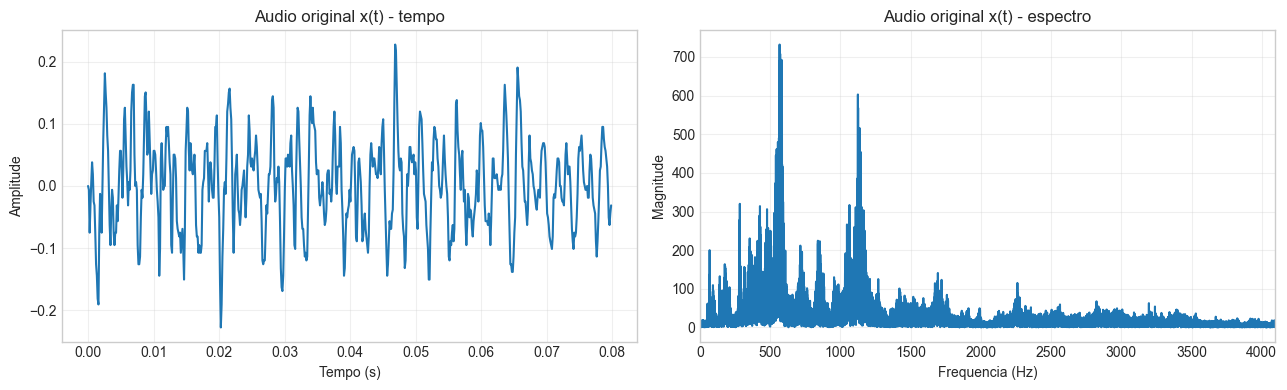

In [2]:

def normalize_audio(x):
    x = np.asarray(x)
    if x.ndim > 1:
        x = np.mean(x, axis=1)
    if np.issubdtype(x.dtype, np.integer):
        max_value = np.iinfo(x.dtype).max
        return x.astype(np.float64) / max_value
    return x.astype(np.float64)


fs_audio, audio_raw = wavfile.read(DATA_DIR / 'handel.wav')
x = normalize_audio(audio_raw)
t = np.arange(len(x)) / fs_audio

print(f'fs do arquivo: {fs_audio} Hz')
print(f'duracao: {len(x) / fs_audio:.2f} s')
print(f'amplitude minima/maxima: {x.min():.4f} / {x.max():.4f}')

plot_time_and_spectrum(x, fs_audio, 'Audio original x(t)', seconds=0.08, xlim_freq=(0, fs_audio / 2))


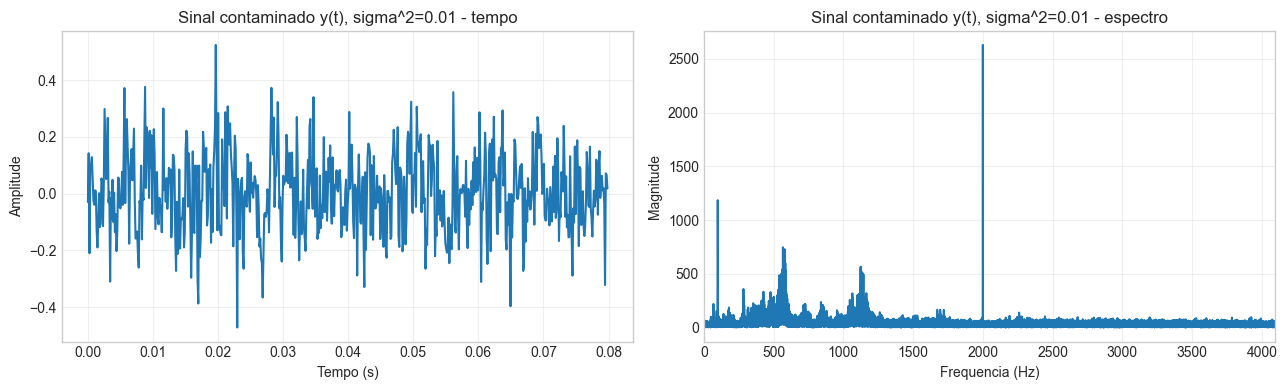

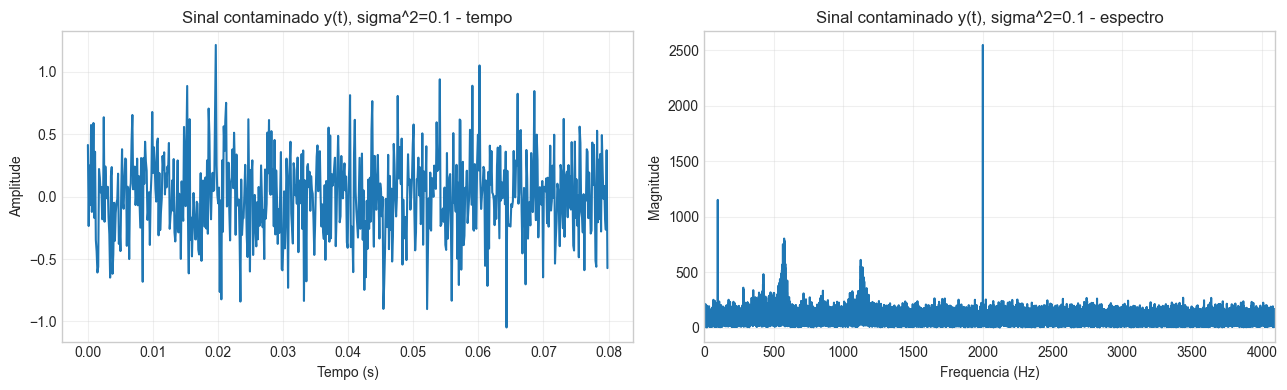

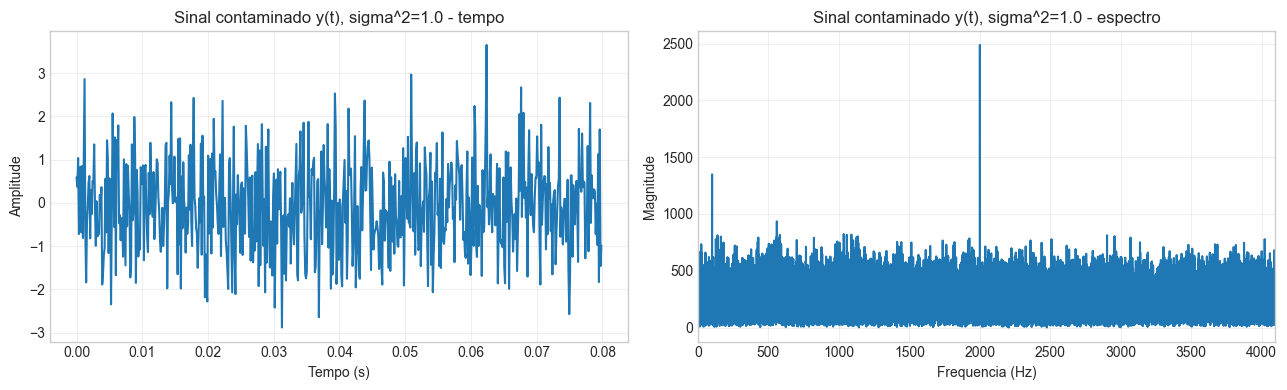

In [3]:

SIGMA2_VALUES = [1e-2, 1e-1, 1.0]
rng = np.random.default_rng(2026)

tone_low = 0.05 * np.cos(200 * np.pi * t)
tone_high = 0.075 * np.sin(4000 * np.pi * t)

contaminated = {}
for sigma2 in SIGMA2_VALUES:
    noise = rng.normal(0.0, np.sqrt(sigma2), size=len(x))
    contaminated[sigma2] = x + tone_low + tone_high + noise

for sigma2, y in contaminated.items():
    plot_time_and_spectrum(
        y,
        fs_audio,
        f'Sinal contaminado y(t), sigma^2={sigma2}',
        seconds=0.08,
        xlim_freq=(0, fs_audio / 2),
    )


Analise espectral:

- A componente de 100 Hz aparece como interferencia tonal de baixa frequencia. Com a restricao atual, ela e atenuada por um passa-altas, mas isso tambem remove parte dos graves do audio.
- A componente de 2000 Hz aparece como interferencia tonal de alta frequencia. Com a restricao atual, ela e atenuada por um passa-baixas, mas isso tambem remove conteudo acima da frequencia de corte.
- O ruido branco se espalha por toda a banda. Filtros passa-baixas/passa-altas reduzem apenas partes da banda; a parcela de ruido dentro da banda preservada permanece.

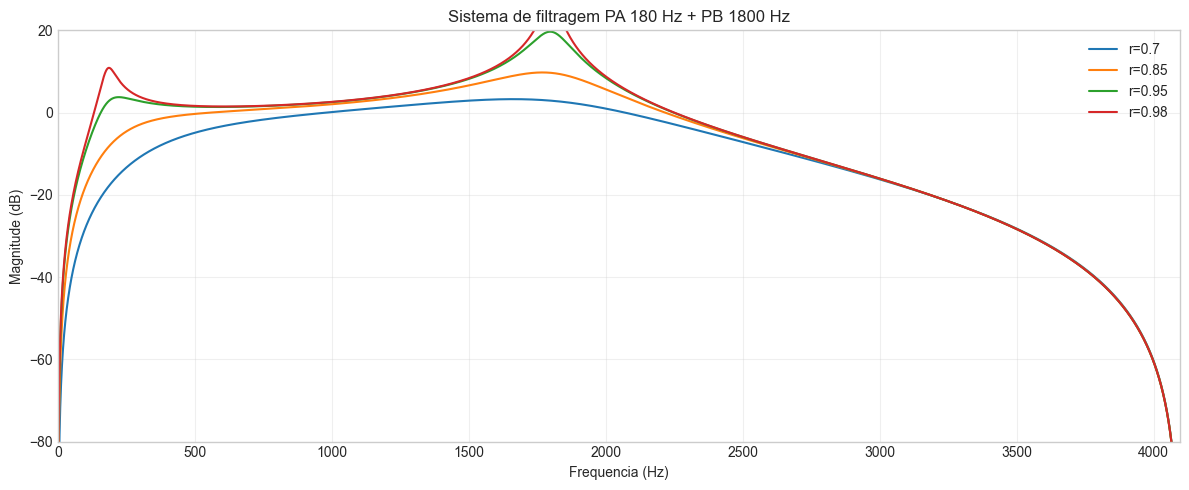

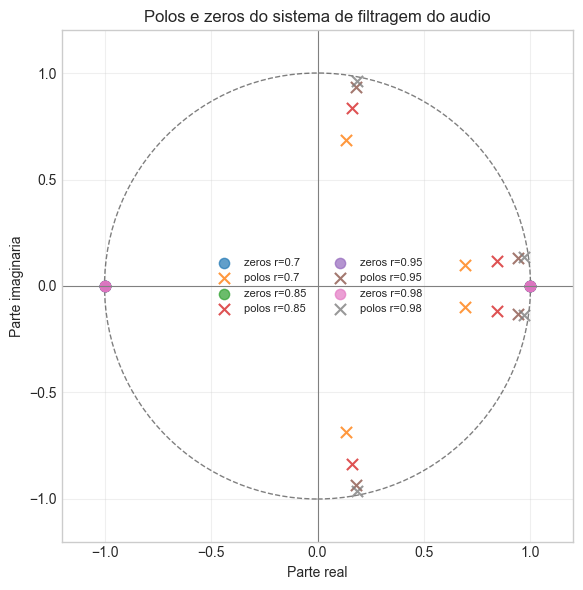

Filtro                   | b                                                          | a                                          | Estavel | Raio max polo | Ganho max (dB) | Largura aprox (Hz) | Zeros          | Polos                                                             
-------------------------+------------------------------------------------------------+--------------------------------------------+---------+---------------+----------------+--------------------+----------------+-------------------------------------------------------------------
PA 180 + PB 1800, r=0.7  | [0.2203, 1.40335e-17, -0.440601, -1.40335e-17, 0.2203]     | [1, -1.65138, 1.34705, -0.809174, 0.2401]  | True    | 0.70000       | 3.28084        | 1031.50000         | [-1, -1, 1, 1] | [0.1323+0.6874j, 0.1323-0.6874j, 0.6933+0.09633j, 0.6933-0.09633j]
PA 180 + PB 1800, r=0.85 | [0.298284, -2.07362e-17, -0.596568, 2.07362e-17, 0.298284] | [1, -2.00524, 1.98621, -1.44879, 0.522006] | True    | 0.85000       

In [4]:

def q5_blocks(r):
    return [
        basic_highpass(180, fs_audio, r),
        basic_lowpass(1800, fs_audio, r),
    ]


def q5_filter(r):
    return cascade(q5_blocks(r))


filters = {f'r={r}': q5_filter(r) for r in R_VALUES}
plot_response_family(filters, 'Sistema de filtragem PA 180 Hz + PB 1800 Hz', fs_audio, xlim=(0, fs_audio / 2))
plot_pole_zero_family(filters, 'Polos e zeros do sistema de filtragem do audio')

rows = []
for r in R_VALUES:
    b, a = q5_filter(r)
    rows.append(filter_summary(f'PA 180 + PB 1800, r={r}', b, a, fs_audio, 'bandpass'))

display_rows(rows, float_digits=5)


In [5]:

def snr_db(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    error = reference - estimate
    signal_power = np.mean(reference**2)
    error_power = np.mean(error**2)
    return float(10 * np.log10(signal_power / max(error_power, 1e-20)))


def mse(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    return float(np.mean((reference - estimate) ** 2))


filtered = {}
rows = []
for sigma2, y in contaminated.items():
    rows.append(
        {
            'sigma^2': sigma2,
            'r': '-',
            'SNR entrada (dB)': snr_db(x, y),
            'SNR saida (dB)': '-',
            'MSE saida': '-',
            'Pot. ruido residual': '-',
        }
    )
    for r in R_VALUES:
        sos = sos_from_blocks(q5_blocks(r))
        x_hat = signal.sosfilt(sos, y)
        filtered[(sigma2, r)] = x_hat
        residual = x - x_hat
        rows.append(
            {
                'sigma^2': sigma2,
                'r': r,
                'SNR entrada (dB)': snr_db(x, y),
                'SNR saida (dB)': snr_db(x, x_hat),
                'MSE saida': mse(x, x_hat),
                'Pot. ruido residual': float(np.mean(residual**2)),
            }
        )

display_rows(rows, float_digits=6)


sigma^2  | r        | SNR entrada (dB) | SNR saida (dB) | MSE saida | Pot. ruido residual
---------+----------+------------------+----------------+-----------+--------------------
0.010000 | -        | 4.393380         | -              | -         | -                  
0.010000 | 0.700000 | 4.393380         | 0.052543       | 0.038045  | 0.038045           
0.010000 | 0.850000 | 4.393380         | -1.174623      | 0.050468  | 0.050468           
0.010000 | 0.950000 | 4.393380         | -4.553696      | 0.109880  | 0.109880           
0.010000 | 0.980000 | 4.393380         | -7.699612      | 0.226731  | 0.226731           
0.100000 | -        | -4.276012        | -              | -         | -                  
0.100000 | 0.700000 | -4.276012        | -3.692657      | 0.090119  | 0.090119           
0.100000 | 0.850000 | -4.276012        | -6.852574      | 0.186555  | 0.186555           
0.100000 | 0.950000 | -4.276012        | -11.534820     | 0.548318  | 0.548318           
0.100000 |

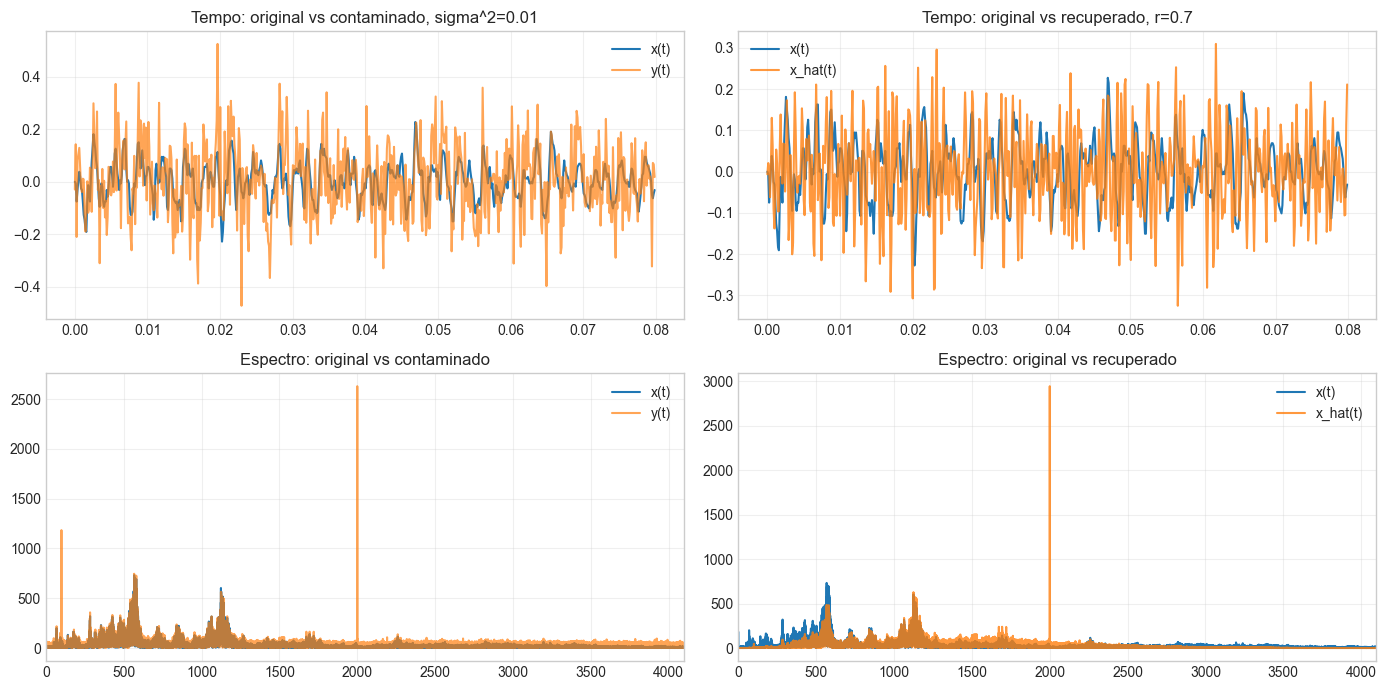

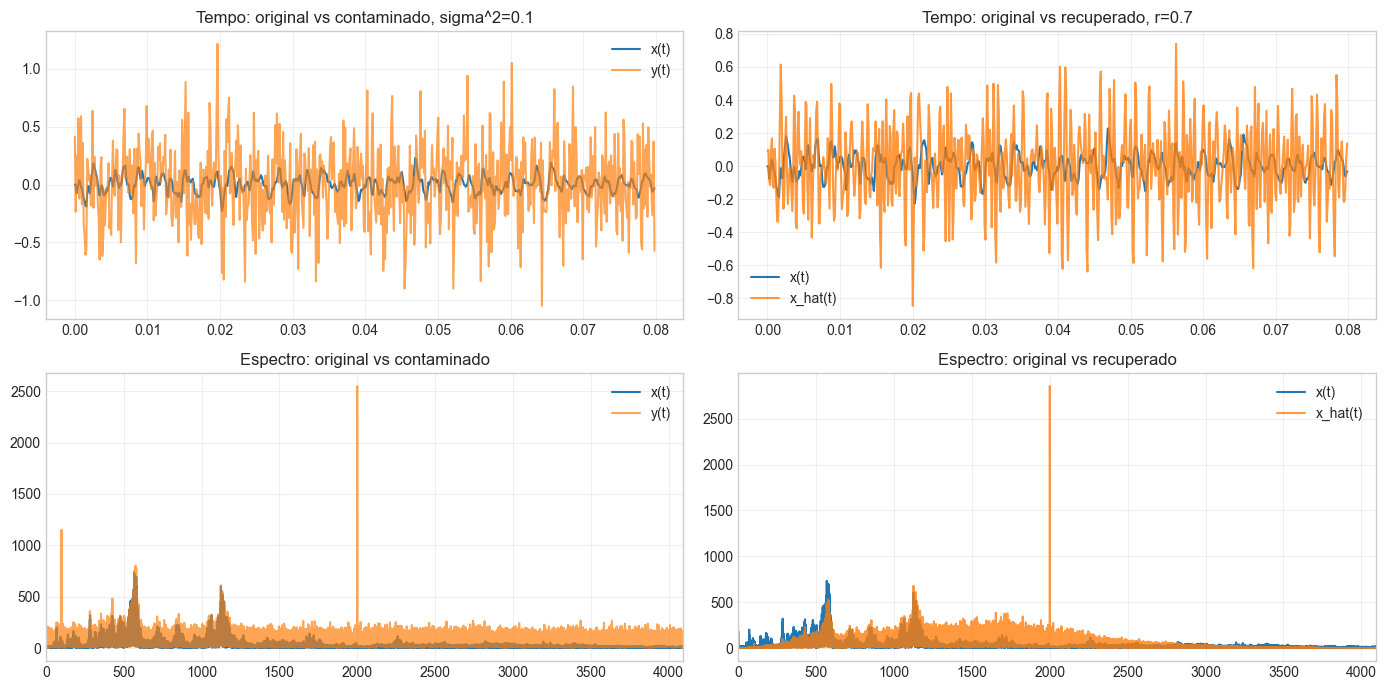

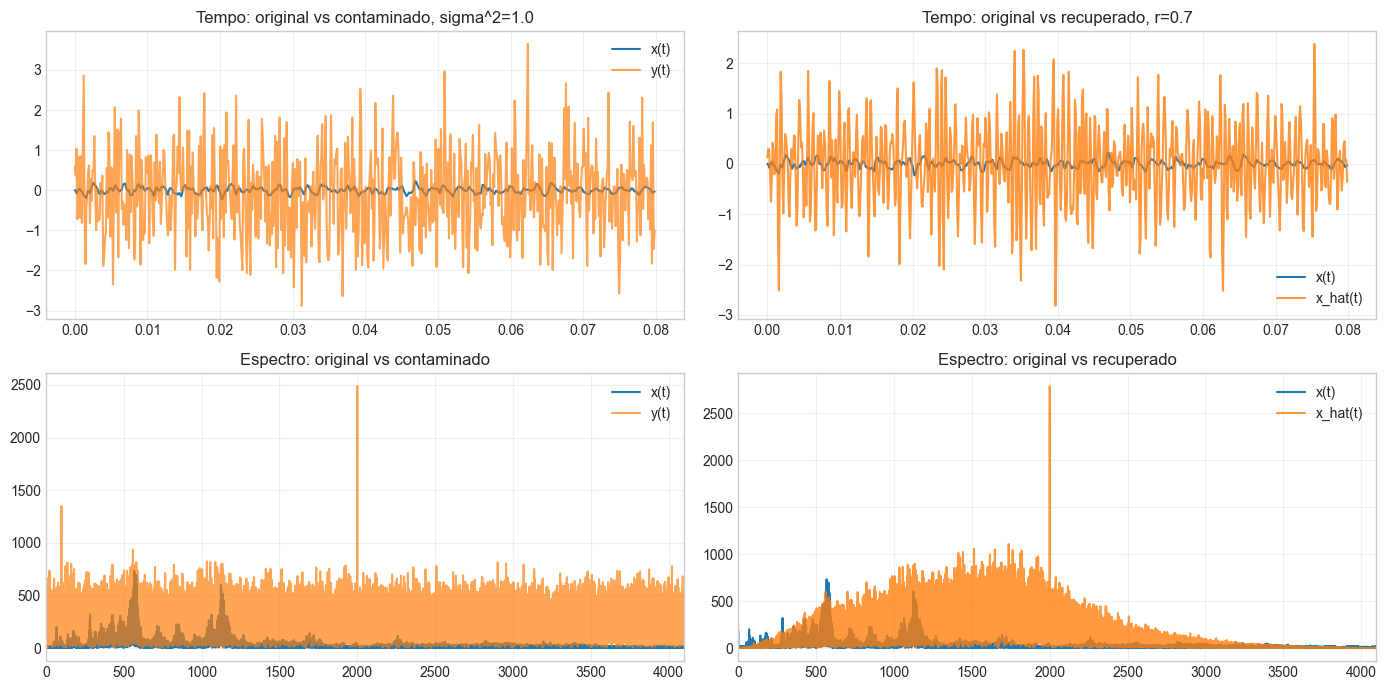

In [6]:

selected_r = 0.70
for sigma2 in SIGMA2_VALUES:
    y = contaminated[sigma2]
    x_hat = filtered[(sigma2, selected_r)]
    n = min(len(x), int(0.08 * fs_audio))
    tt = np.arange(n) / fs_audio

    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    axes[0, 0].plot(tt, x[:n], label='x(t)')
    axes[0, 0].plot(tt, y[:n], label='y(t)', alpha=0.7)
    axes[0, 0].set_title(f'Tempo: original vs contaminado, sigma^2={sigma2}')
    axes[0, 0].legend()

    axes[0, 1].plot(tt, x[:n], label='x(t)')
    axes[0, 1].plot(tt, x_hat[:n], label='x_hat(t)', alpha=0.8)
    axes[0, 1].set_title(f'Tempo: original vs recuperado, r={selected_r}')
    axes[0, 1].legend()

    freqs = np.fft.rfftfreq(len(x), 1 / fs_audio)
    axes[1, 0].plot(freqs, np.abs(np.fft.rfft(x)), label='x(t)')
    axes[1, 0].plot(freqs, np.abs(np.fft.rfft(y)), label='y(t)', alpha=0.7)
    axes[1, 0].set_title('Espectro: original vs contaminado')
    axes[1, 0].set_xlim(0, fs_audio / 2)
    axes[1, 0].legend()

    axes[1, 1].plot(freqs, np.abs(np.fft.rfft(x)), label='x(t)')
    axes[1, 1].plot(freqs, np.abs(np.fft.rfft(x_hat)), label='x_hat(t)', alpha=0.8)
    axes[1, 1].set_title('Espectro: original vs recuperado')
    axes[1, 1].set_xlim(0, fs_audio / 2)
    axes[1, 1].legend()

    for ax in axes.ravel():
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [7]:

try:
    from IPython.display import Audio, display

    selected_sigma2 = 1e-1
    selected_r = 0.70
    print('Audio original:')
    display(Audio(x, rate=fs_audio))
    print(f'Audio contaminado, sigma^2={selected_sigma2}:')
    display(Audio(contaminated[selected_sigma2], rate=fs_audio))
    print(f'Audio recuperado, r={selected_r}:')
    display(Audio(filtered[(selected_sigma2, selected_r)], rate=fs_audio))
except Exception as exc:
    print(f'Reproducao de audio indisponivel neste ambiente: {exc}')


Audio original:


Audio contaminado, sigma^2=0.1:


Audio recuperado, r=0.7:


Avaliacao subjetiva esperada:

- A filtragem reduz os tons de 100 Hz e 2000 Hz, mas nao os remove de forma tao limpa quanto filtros notch.
- Para `sigma^2 = 10^-2`, o audio recuperado tende a ficar mais inteligivel porque o ruido e moderado.
- Para `sigma^2 = 10^-1`, ainda ha melhora nas interferencias tonais, mas o ruido residual fica perceptivel.
- Para `sigma^2 = 1`, o ruido branco domina grande parte da banda e a recuperacao fica limitada.
- Valores maiores de `r` tornam as transicoes mais seletivas, mas podem criar picos e maior sensibilidade numerica.